# Data Engineering

In [1]:
import pandas as pd
import numpy as np
from ast import literal_eval
import re
import csv

In [113]:
#Leer CSV con los datos
df = pd.read_csv('casas_idealista2.csv', sep=';', encoding='utf-16')
df.head()

,titulo,localizacion,precio,caracteristicas_basicas,caracteristicas_extras
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,"['35 m² construidos', '1 habitación', '1 baño'...","['Consumo:', 'Emisiones:']"
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,"['120 m² construidos', '3 habitaciones', '2 ba...","['Aire acondicionado', 'Consumo: \n999 kWh/m² ..."
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,"['45 m² construidos', '2 habitaciones', '1 bañ...","['Aire acondicionado', 'Consumo:', 'Emisiones:']"
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,"['100 m² construidos', '3 habitaciones', '1 ba...",['Consumo: \n999 kWh/m² año']
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,"['55 m² construidos, 50 m² útiles', '1 habitac...","['Consumo: \n150 kWh/m² año', 'Emisiones: \n90..."


In [114]:
df = pd.read_csv('casas_idealista2.csv', sep=';', encoding='utf-16', converters={'caracteristicas_basicas': literal_eval, 'caracteristicas_extras': literal_eval})
df.head()

,titulo,localizacion,precio,caracteristicas_basicas,caracteristicas_extras
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,"[35 m² construidos, 1 habitación, 1 baño, Balc...","[Consumo:, Emisiones:]"
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,"[120 m² construidos, 3 habitaciones, 2 baños, ...","[Aire acondicionado, Consumo: \n999 kWh/m² año]"
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,"[45 m² construidos, 2 habitaciones, 1 baño, Ba...","[Aire acondicionado, Consumo:, Emisiones:]"
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,"[100 m² construidos, 3 habitaciones, 1 baño, T...",[Consumo: \n999 kWh/m² año]
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,"[55 m² construidos, 50 m² útiles, 1 habitación...","[Consumo: \n150 kWh/m² año, Emisiones: \n90 kg..."


In [115]:
df.caracteristicas_basicas[35]

['85 m² construidos, 81 m² útiles',
 '2 habitaciones',
 '1 baño',
 'Plaza de garaje incluida en el precio',
 'Segunda mano/buen estado',
 'Armarios empotrados',
 'Amueblado y cocina equipada',
 'Planta 1ª exterior',
 'Con ascensor']

In [116]:
def match_property(property, patterns):
    for pat in patterns:
        match_prop = re.search(pat, property)
        if match_prop:
            return True
    return False        

In [117]:
match_property('con trastero', ['con'])

True

In [118]:
def check_property(property, patterns):
    for pat in patterns:
        check = re.search(pat, property)
        if check:
            return 1
    return 0        

In [119]:
check_property('con trastero', ['con'])

1

In [120]:
def get_number(property):
    nums = re.findall(r'\d', property)
    if len(nums) == 2:
        return int(nums[0] + nums[1])
    else:
        return int(nums[0])

In [121]:
get_number('2 baños')

2

In [122]:
def get_ascensor(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['ascensor']):
            return(check_property(prop.lower().strip(), ['con']))

In [123]:
get_ascensor(['con ascensor'])

1

In [124]:
get_ascensor(['sin ascensor'])

0

In [125]:
def get_baños(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['baño']):
            return(get_number(prop.lower().strip()))

In [126]:
get_baños(['3 baños'])

3

In [127]:
def get_año(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['construido en']):
            return(get_number(prop.lower().strip()))

In [128]:
def get_trastero(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['trastero']):
            value +=1
    return(value)              

In [129]:
def get_orientacion(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['orientacion']):
            return(prop.split(' ', maxsplit=1)[1].strip().split(', ')[0])

In [130]:
def get_piso(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['bajo','planta','interior','exterior']):
            return(prop)

In [131]:
def get_habitaciones(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['habitaci']):
            try:
                habitaciones = get_number(prop.lower().strip())
            except:
                habitaciones = prop
            return(habitaciones)    

In [132]:
def get_metros_reales(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['m²']):
            try:
                metros = get_number(prop.lower().strip().split(',')[0])
            except:
                metros = prop
            return(metros)    

In [133]:
def get_condicion(features):
    for prop in features:
        if match_property(prop.lower().strip(), ['segunda mano', 'promocion de obra nueva']):
            return(prop)

In [134]:
def get_terraza(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['terraza']):
            value +=1
    return(value)        

In [135]:
def get_balcon(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['balcon']):
            value +=1
    return(value)    

In [136]:
def get_jardin(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['jardin']):
            value +=1
    return(value)    

In [137]:
def get_garaje(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['garaje']):
            value +=1
    return(value)    

In [138]:
def get_calefaccion(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['calefacción']):
            value +=1
    return(value)    

In [139]:
def get_aire_acon(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['aire acondicionado']):
            value +=1
    return(value)    

In [140]:
def get_armario_empotrado(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['armarios empotrados']):
            value +=1
    return(value)        

In [141]:
def get_piscina(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['piscina']):
            value +=1
    return(value)    

In [142]:
def get_zonas_verdes(features):
    value = 0
    for prop in features:
        if match_property(prop.lower().strip(), ['zonas verdes']):
            value +=1
    return(value)    

In [143]:
df['ascensor'] = df.caracteristicas_basicas.apply(get_ascensor)
df['baños'] = df.caracteristicas_basicas.apply(get_baños)
df['año'] = df.caracteristicas_basicas.apply(get_año)
df['trastero'] = df.caracteristicas_basicas.apply(get_trastero)
df['orientacion'] = df.caracteristicas_basicas.apply(get_orientacion)
df['piso'] = df.caracteristicas_basicas.apply(get_piso)
df['habitaciones'] = df.caracteristicas_basicas.apply(get_habitaciones)
df['metros_reales'] = df.caracteristicas_basicas.apply(get_metros_reales)
df['condicion'] = df.caracteristicas_basicas.apply(get_condicion)
df['armarios_empotrados'] = df.caracteristicas_basicas.apply(get_armario_empotrado)
df['terraza'] = df.caracteristicas_basicas.apply(get_terraza)
df['balcon'] = df.caracteristicas_extras.apply(get_balcon)
df['jardin'] = df.caracteristicas_basicas.apply(get_jardin)
df['garaje'] = df.caracteristicas_basicas.apply(get_garaje)
df['calefaccion'] = df.caracteristicas_basicas.apply(get_calefaccion)
df['aire_acondicionado'] = df.caracteristicas_extras.apply(get_aire_acon)
df['piscina'] = df.caracteristicas_extras.apply(get_piscina)
df['zonas_verdes'] = df.caracteristicas_extras.apply(get_zonas_verdes)

In [144]:
df.head(5)

,titulo,localizacion,precio,caracteristicas_basicas,caracteristicas_extras,ascensor,baños,año,trastero,orientacion,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,"[35 m² construidos, 1 habitación, 1 baño, Balc...","[Consumo:, Emisiones:]",0.0,1,NaN,0,None,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,"[120 m² construidos, 3 habitaciones, 2 baños, ...","[Aire acondicionado, Consumo: \n999 kWh/m² año]",1.0,2,NaN,0,None,...,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,"[45 m² construidos, 2 habitaciones, 1 baño, Ba...","[Aire acondicionado, Consumo:, Emisiones:]",0.0,1,NaN,0,None,...,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,"[100 m² construidos, 3 habitaciones, 1 baño, T...",[Consumo: \n999 kWh/m² año],NaN,1,NaN,0,None,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,"[55 m² construidos, 50 m² útiles, 1 habitación...","[Consumo: \n150 kWh/m² año, Emisiones: \n90 kg...",1.0,1,2.0,0,None,...,Segunda mano/buen estado,1,0,0,0,1,1,0,0,0


In [145]:
df.drop(columns = ['caracteristicas_basicas', 'caracteristicas_extras'], inplace = True)
df.head(5)

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,0.0,1,NaN,0,None,Planta 1ª exterior,1,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,1.0,2,NaN,0,None,None,3,...,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,NaN,0,None,Planta 4ª exterior,2,...,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,NaN,1,NaN,0,None,None,3,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,1.0,1,2.0,0,None,Planta 2ª exterior,1,...,Segunda mano/buen estado,1,0,0,0,1,1,0,0,0


# EDA

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
df.iloc[1:4]

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,1.0,2,NaN,0,None,None,3,...,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,NaN,0,None,Planta 4ª exterior,2,...,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,NaN,1,NaN,0,None,None,3,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0


In [148]:
df.describe()

,precio,ascensor,baños,año,trastero,metros_reales,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
count,1254.000000,1120.000000,1254.000000,289.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.0,1254.0,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000
mean,929.167464,0.745536,1.493620,1.346021,0.137161,42.798246,0.466507,0.399522,0.0,0.0,0.248804,0.714514,0.512759,0.128389,0.098884
std,298.137832,0.435754,0.621155,0.476525,0.344155,36.979449,0.499076,0.489995,0.0,0.0,0.432492,0.451826,0.500037,0.334656,0.298625
min,300.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,700.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,850.000000,1.000000,1.000000,1.000000,0.000000,50.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,1.000000,0.000000,0.000000
75%,1100.000000,1.000000,2.000000,2.000000,0.000000,80.000000,1.000000,1.000000,0.0,0.0,0.000000,1.000000,1.000000,0.000000,0.000000
max,3000.000000,1.000000,5.000000,2.000000,1.000000,99.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


# Pairplots

In [149]:
vars1 = ['baños','ascensor','trastero','metros_reales','armarios_empotrados'] + ['precio']
vars2 = ['terraza','balcon','jardin','garaje','calefaccion', 'aire_acondicionado'] + ['precio']

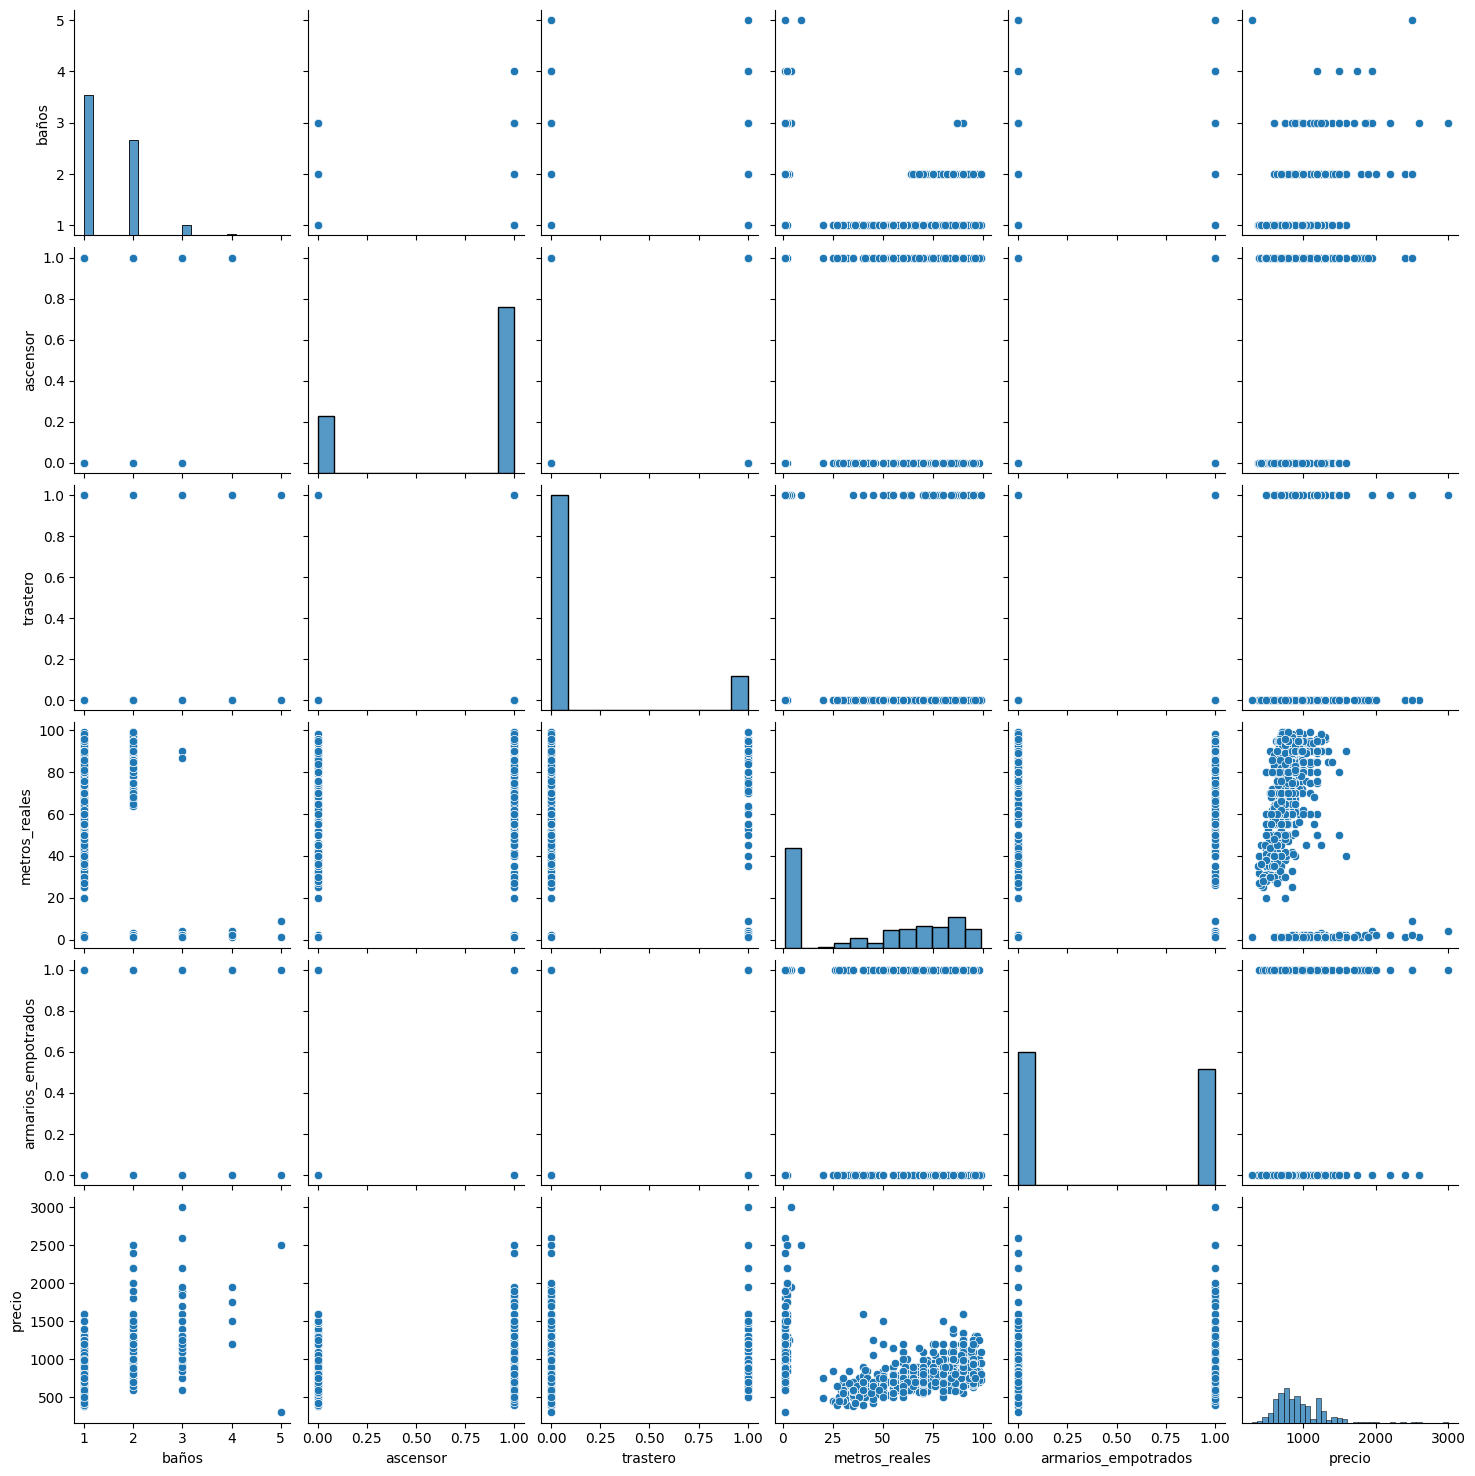

In [150]:
pair_plot = sns.pairplot(df[vars1])
plt.show()

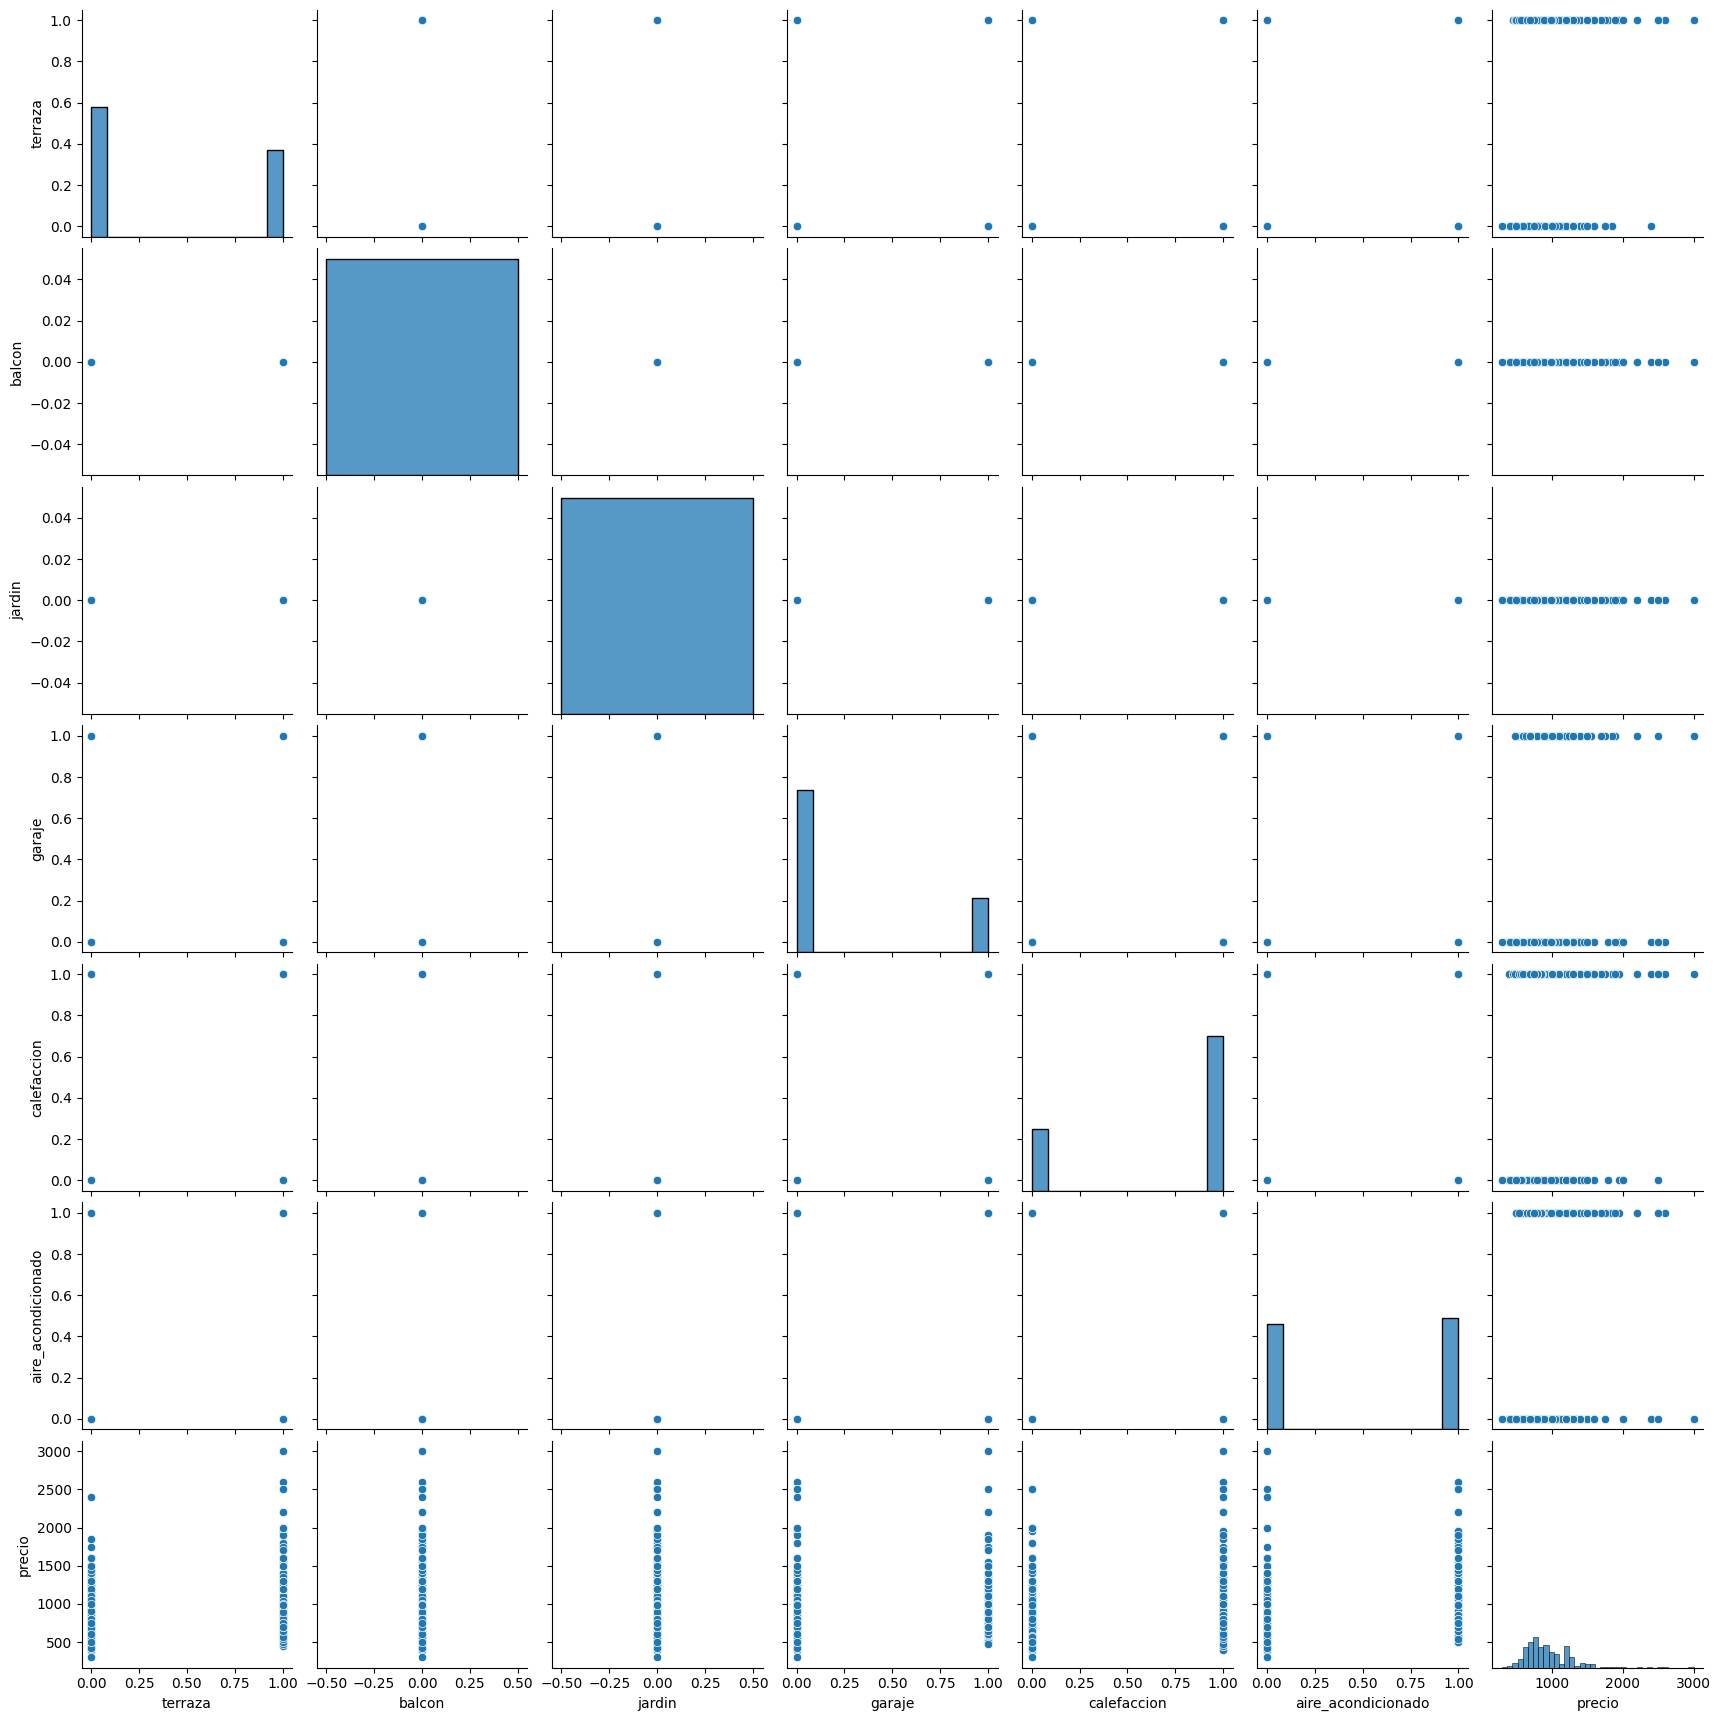

In [151]:
pair_plot = sns.pairplot(df[vars2])
plt.show()

## Precio

<Axes: xlabel='precio', ylabel='Count'>

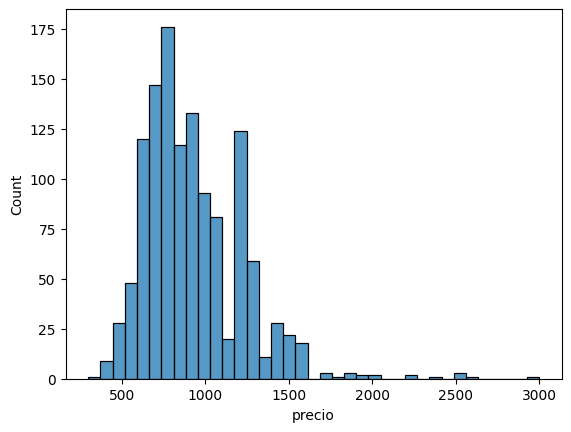

In [152]:
sns.histplot(data=df.precio)

Deberiamos quitar el outlier?

In [153]:
df.loc[df.precio>2000]

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
8,Alquiler de Casa o chalet independiente en San...,Granada,2200,NaN,2,NaN,1,None,1 planta,4,...,Segunda mano/buen estado,0,1,0,0,1,1,1,1,0
81,Alquiler de Piso en Carrera de la Virgen - Pas...,"Realejo, Granada",2400,1.0,2,NaN,0,None,Planta 5ª exterior,6,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
108,Alquiler de Casa o chalet independiente en cal...,"Altos de la Zubia, La Zubia",3000,NaN,3,2.0,1,None,2 plantas,4,...,Segunda mano/buen estado,1,1,0,0,1,1,0,1,0
456,Alquiler de Casa o chalet independiente en cal...,La Zubia,2500,NaN,5,2.0,1,None,3 plantas,5,...,Segunda mano/buen estado,1,1,0,0,1,1,1,1,0
462,Alquiler de Chalet pareado en avenida Cristóba...,"Casco Historico, Churriana de la Vega",2200,NaN,3,NaN,1,None,3 plantas,3,...,Segunda mano/buen estado,1,1,0,0,1,1,1,0,0
607,Alquiler de Casa o chalet independiente en pla...,"Avda. de los Ogijares, Armilla",2600,NaN,3,NaN,0,None,1 planta,8,...,Segunda mano/buen estado,0,1,0,0,0,1,1,0,0
817,Alquiler de Casa o chalet independiente en cal...,"Albaicín, Granada",2500,NaN,2,NaN,0,None,2 plantas,4,...,Segunda mano/buen estado,1,1,0,0,0,0,1,0,0
1240,Alquiler de Piso en avenida de la Constitución...,"Plaza de Toros, Granada",2500,1.0,2,NaN,0,None,Planta 5ª exterior,5,...,Segunda mano/buen estado,1,1,0,0,0,1,0,0,0


Quitamos el outlier que vale 3000

In [155]:
df = df[df.precio < 2700]
df

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,0.0,1,NaN,0,None,Planta 1ª exterior,1,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,1.0,2,NaN,0,None,None,3,...,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,NaN,0,None,Planta 4ª exterior,2,...,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,NaN,1,NaN,0,None,None,3,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,1.0,1,2.0,0,None,Planta 2ª exterior,1,...,Segunda mano/buen estado,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,"Alquiler de Piso en calle Carnicería, 1","San Matías - Pavaneras, Granada",800,1.0,1,NaN,0,None,Planta 2ª exterior,3,...,Segunda mano/buen estado,1,0,0,0,0,1,1,0,0
1250,"Alquiler de Piso en Placeta de Aljucer, 1","San Ildefonso, Granada",800,0.0,1,NaN,0,None,Planta 1ª exterior,3,...,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1251,"Alquiler de Dúplex en Cuba, 10","Aljomahima - Ermita, Las Gabias",700,1.0,2,NaN,0,None,Planta 2ª exterior,3,...,Segunda mano/buen estado,0,1,0,0,1,1,0,1,0
1252,"Alquiler de Piso en calle Estepona, 7","Carrera de la Virgen - Paseo del Salón, Granada",1300,1.0,2,NaN,0,None,Planta 5ª exterior,3,...,Segunda mano/buen estado,0,0,0,0,1,0,1,0,0


## Ascensor

In [156]:
df.ascensor.value_counts()

ascensor
1.0    835
0.0    285
Name: count, dtype: int64

In [157]:
# De cuantas casas no tenemos informacion del ascensor
sum(df.ascensor.isna())

133

In [158]:
df[df.ascensor.isna()]

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,NaN,1,NaN,0,None,None,3,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
8,Alquiler de Casa o chalet independiente en San...,Granada,2200,NaN,2,NaN,1,None,1 planta,4,...,Segunda mano/buen estado,0,1,0,0,1,1,1,1,0
45,Alquiler de Casa o chalet independiente en cal...,"San Ildefonso, Granada",700,NaN,1,NaN,0,None,2 plantas,2,...,Segunda mano/buen estado,0,1,0,0,0,0,0,0,0
46,Alquiler de Casa o chalet independiente en cal...,Atarfe,650,NaN,2,NaN,0,None,2 plantas,2,...,Segunda mano/buen estado,0,1,0,0,0,0,1,0,0
58,Alquiler de Chalet adosado en Barrio de los Pe...,Granada,700,NaN,2,1.0,0,None,1 planta,4,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,Alquiler de Dúplex en Aljomahima - Ermita,Las Gabias,800,NaN,2,NaN,0,None,None,3,...,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1227,Alquiler de Piso en La Chana,Granada,780,NaN,1,NaN,0,None,Planta 2ª,2,...,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1228,Alquiler de Piso en Jardín Botánico,"Centro, Granada",650,NaN,1,NaN,0,None,Planta 1ª,1,...,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1234,"Alquiler de Chalet pareado en via del Tranvía, 15",Cajar,1500,NaN,4,NaN,1,None,3 plantas,3,...,Segunda mano/buen estado,0,1,0,0,1,1,1,0,0


Suponemos que los que no tienen esa informacion, es que no tienen ascensor

In [159]:
#Reemplaza las lineas con na por un 0
df.loc[df['ascensor'].isna(), 'ascensor'] = 0
df

,titulo,localizacion,precio,ascensor,baños,año,trastero,orientacion,piso,habitaciones,...,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,0.0,1,NaN,0,None,Planta 1ª exterior,1,...,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,1.0,2,NaN,0,None,None,3,...,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,NaN,0,None,Planta 4ª exterior,2,...,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,0.0,1,NaN,0,None,None,3,...,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,1.0,1,2.0,0,None,Planta 2ª exterior,1,...,Segunda mano/buen estado,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,"Alquiler de Piso en calle Carnicería, 1","San Matías - Pavaneras, Granada",800,1.0,1,NaN,0,None,Planta 2ª exterior,3,...,Segunda mano/buen estado,1,0,0,0,0,1,1,0,0
1250,"Alquiler de Piso en Placeta de Aljucer, 1","San Ildefonso, Granada",800,0.0,1,NaN,0,None,Planta 1ª exterior,3,...,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1251,"Alquiler de Dúplex en Cuba, 10","Aljomahima - Ermita, Las Gabias",700,1.0,2,NaN,0,None,Planta 2ª exterior,3,...,Segunda mano/buen estado,0,1,0,0,1,1,0,1,0
1252,"Alquiler de Piso en calle Estepona, 7","Carrera de la Virgen - Paseo del Salón, Granada",1300,1.0,2,NaN,0,None,Planta 5ª exterior,3,...,Segunda mano/buen estado,0,0,0,0,1,0,1,0,0


## Baños

In [160]:
df.baños.value_counts()

baños
1    708
2    483
3     54
4      6
5      2
Name: count, dtype: int64

## Año

In [161]:
df.año.isna().sum()

np.int64(965)

Se elimina la columna año por tener pocos datos

In [162]:
df.drop(columns = ['año'], inplace = True)

## Trastero

In [163]:
df.trastero.value_counts()

trastero
0    1082
1     171
Name: count, dtype: int64

## Orientacion

In [164]:
df[df.orientacion.isna()]

,titulo,localizacion,precio,ascensor,baños,trastero,orientacion,piso,habitaciones,metros_reales,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,0.0,1,0,None,Planta 1ª exterior,1,35,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
1,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1200,1.0,2,0,None,None,3,1,Segunda mano/buen estado,1,0,0,0,0,0,1,0,0
2,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,0,None,Planta 4ª exterior,2,45,Segunda mano/buen estado,0,0,0,0,0,0,1,0,0
3,Alquiler de Piso en calle Aretusa,"Barrio de los Periodistas, Granada",1050,0.0,1,0,None,None,3,1,Segunda mano/buen estado,1,1,0,0,0,0,0,0,0
4,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,1.0,1,0,None,Planta 2ª exterior,1,55,Segunda mano/buen estado,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,"Alquiler de Piso en calle Carnicería, 1","San Matías - Pavaneras, Granada",800,1.0,1,0,None,Planta 2ª exterior,3,1,Segunda mano/buen estado,1,0,0,0,0,1,1,0,0
1250,"Alquiler de Piso en Placeta de Aljucer, 1","San Ildefonso, Granada",800,0.0,1,0,None,Planta 1ª exterior,3,70,Segunda mano/buen estado,0,0,0,0,0,0,0,0,0
1251,"Alquiler de Dúplex en Cuba, 10","Aljomahima - Ermita, Las Gabias",700,1.0,2,0,None,Planta 2ª exterior,3,1,Segunda mano/buen estado,0,1,0,0,1,1,0,1,0
1252,"Alquiler de Piso en calle Estepona, 7","Carrera de la Virgen - Paseo del Salón, Granada",1300,1.0,2,0,None,Planta 5ª exterior,3,1,Segunda mano/buen estado,0,0,0,0,1,0,1,0,0


Se elimna la columna por la casi inexistencia de datos

In [165]:
df.drop(columns = ['orientacion'], inplace = True)

## Piso

In [166]:
df.piso.value_counts()

piso
Planta 1ª exterior      251
Planta 2ª exterior      203
Planta 3ª exterior      174
Bajo exterior           108
Planta 4ª exterior      103
Planta 5ª exterior       68
Planta 6ª exterior       41
3 plantas                30
1 planta                 28
2 plantas                28
Planta 7ª exterior       21
Planta 1ª                18
Planta 1ª interior       15
Planta 3ª                14
Planta 3ª interior       14
Planta 2ª interior       11
Entreplanta exterior     11
Planta 4ª                 9
Bajo interior             8
Planta 9ª exterior        7
Planta 2ª                 7
Planta 8ª exterior        6
exterior                  6
Bajo                      6
Planta 5ª interior        5
Planta 5ª                 4
Planta 4ª interior        4
Planta -2 exterior        3
Planta 7ª                 3
Planta 12ª exterior       3
4 plantas                 3
Planta 10ª exterior       2
Planta 6ª                 2
Planta 8ª interior        2
Planta 14ª exterior       1
Planta 11ª exte

In [167]:
df.piso.isna().sum()

np.int64(30)

Como el dataframe no es reciente y quizas no existan los anuncios se eliminan aquellos sin el dato piso

In [168]:
df = df[~df.piso.isna()]

In [181]:
def process_piso(serie):
    lista = serie.split()
    mapeo = ''
    if ((lista[0] == 'Bajo') | (lista[0] == 'Entreplanta') | (lista[0] == 'Exterior')):
        mapeo = 'Bajo'
    elif lista[0] == 'Planta':
        try:           
            if int(lista[1][0]) < 4:
                mapeo = 'Primeros_pisos'
            else:
                mapeo = 'Ultimos_pisos'
        #Excepcion que ocurre con aquellos que incluyen un signo antes del número,         
        except ValueError:
            if int(lista[1][1]) < 4:
                mapeo = 'Primeros_pisos'
            else:
                mapeo = 'Ultimos_pisos'              
    else:
        mapeo = 'Muchas_plantas'
    return(mapeo)    

In [182]:
df.piso = df.piso.apply(process_piso)
df.piso

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25904\2273962139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.piso = df.piso.apply(process_piso)


0       Primeros_pisos
2        Ultimos_pisos
4       Primeros_pisos
6       Primeros_pisos
8       Muchas_plantas
             ...      
1249    Primeros_pisos
1250    Primeros_pisos
1251    Primeros_pisos
1252     Ultimos_pisos
1253              Bajo
Name: piso, Length: 1223, dtype: object

In [183]:
df.piso.value_counts()

piso
Primeros_pisos    717
Ultimos_pisos     278
Bajo              133
Muchas_plantas     95
Name: count, dtype: int64

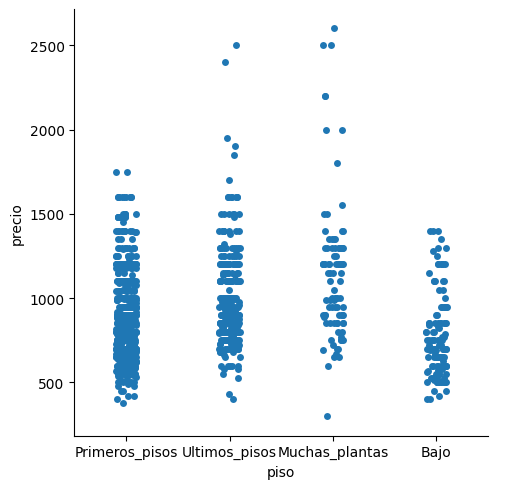

In [185]:
sns.catplot(x='piso', y='precio', data=df)

## Habitaciones

In [186]:
df.habitaciones.value_counts()

habitaciones
3                 419
2                 252
4                 236
1                 209
Sin habitación     59
5                  41
6                   6
8                   1
Name: count, dtype: int64

In [187]:
df[df.habitaciones == 'Sin habitación']

,titulo,localizacion,precio,ascensor,baños,trastero,piso,habitaciones,metros_reales,condicion,armarios_empotrados,terraza,balcon,jardin,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
19,Alquiler de Estudio en Molinos - Santiago,"Realejo, Granada",420,0.0,1,0,Bajo,Sin habitación,45,Segunda mano/buen estado,0,0,0,0,0,0,0,0,1
86,Alquiler de Estudio en cuesta de Rodrigo del C...,"Molinos - Santiago, Granada",450,0.0,1,0,Primeros_pisos,Sin habitación,25,Segunda mano/buen estado,0,1,0,0,0,1,0,0,0
88,Alquiler de Estudio en calle Honda del Realejo,"Molinos - Santiago, Granada",600,1.0,1,0,Ultimos_pisos,Sin habitación,30,Segunda mano/buen estado,0,0,0,0,0,1,1,0,0
186,"Alquiler de Estudio en Pintor Lopez Mezquita, 14","Gran Capitán, Granada",400,1.0,1,0,Ultimos_pisos,Sin habitación,32,Segunda mano/buen estado,1,0,0,0,0,1,0,0,0
194,Alquiler de Estudio en calle Nuestra Señora de...,"Los Pajaritos, Granada",525,1.0,1,0,Bajo,Sin habitación,40,Segunda mano/buen estado,0,0,0,0,0,1,1,0,0
199,Alquiler de Estudio en calle Ribera del Beiro,"San Francisco Javier, Granada",525,0.0,1,0,Bajo,Sin habitación,35,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
202,Alquiler de Estudio en avenida Avenue Avenue D...,"Plaza de Toros, Granada",525,0.0,1,0,Bajo,Sin habitación,32,Segunda mano/buen estado,0,0,0,0,0,1,0,0,0
282,Alquiler de Estudio en avenida de la Ilustraci...,"Campus de la Salud, Granada",800,1.0,1,0,Primeros_pisos,Sin habitación,47,Segunda mano/buen estado,0,1,0,0,1,1,1,1,0
341,Alquiler de Estudio en Placeta del Hospicio Vi...,"Molinos - Santiago, Granada",700,0.0,1,0,Bajo,Sin habitación,30,Segunda mano/buen estado,1,0,0,0,0,0,0,0,0
453,Alquiler de Estudio en calle Martínez de la Rosa,"Ronda - Arabial, Granada",775,1.0,1,0,Primeros_pisos,Sin habitación,40,Segunda mano/buen estado,1,0,0,0,0,1,0,0,0


In [188]:
df.loc[df.habitaciones == 'Sin habitación', 'habitaciones'] = 1

## Metros reales

In [195]:
df.metros_reales.describe()

count    1223.000000
mean       43.345871
std        37.033544
min         1.000000
25%         1.000000
50%        50.000000
75%        80.000000
max        99.000000
Name: metros_reales, dtype: float64

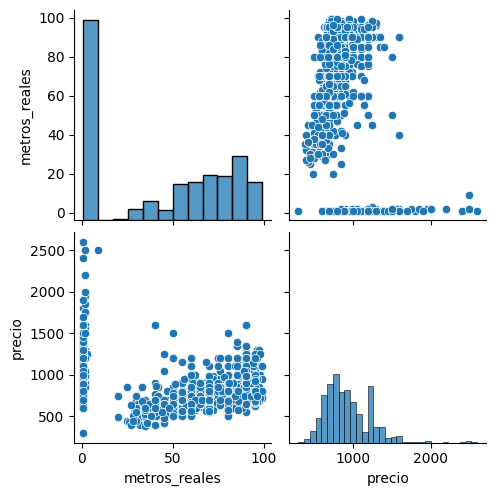

In [192]:
sns.pairplot(df[['metros_reales', 'precio']])

## Condición

In [196]:
df.condicion.value_counts()

condicion
Segunda mano/buen estado      1205
Segunda mano/para reformar       4
Name: count, dtype: int64

## Armarios empotrados

In [197]:
df.armarios_empotrados.value_counts()

armarios_empotrados
0    651
1    572
Name: count, dtype: int64

## Terraza

In [198]:
df.terraza.value_counts()

terraza
0    735
1    488
Name: count, dtype: int64

## Balcon

In [199]:
df.balcon.value_counts()

balcon
0    1223
Name: count, dtype: int64

Eliminamos porque no aporta informacion

In [202]:
df.drop('balcon', inplace=True, axis=1)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25904\134479243.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('balcon', inplace=True, axis=1)


## Jardin

In [200]:
df.jardin.value_counts()

jardin
0    1223
Name: count, dtype: int64

Eliminamos porque no aporta informacion

In [ ]:
df.drop('jardin', inplace=True, axis=1)

## Garaje

In [204]:
df.garaje.value_counts()

garaje
0    917
1    306
Name: count, dtype: int64

## Calefaccion

In [205]:
df.calefaccion.value_counts()

calefaccion
1    889
0    334
Name: count, dtype: int64

## Aire Acondicionado

In [206]:
df.aire_acondicionado.value_counts()

aire_acondicionado
1    628
0    595
Name: count, dtype: int64

In [207]:
df.to_csv('idealista_machine_learning.csv', index = False)